In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("bengaluru_house_prices.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df=df.drop(["area_type","availability","society"],axis=1)
df.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [5]:
df["location"].nunique()

1305

In [6]:
df.shape

(13320, 6)

In [7]:
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

In [8]:
df["balcony"].unique()

array([ 1.,  3., nan,  2.,  0.])

In [9]:
df.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(12710, 6)

In [12]:
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  1.,  8.,  7.,  6.,  9., 27., 11., 12., 10.,
       40., 15., 13.])

In [13]:
df["balcony"].unique()

array([1., 3., 2., 0.])

In [14]:
df[df["bath"]>10].head(10)

,location,size,total_sqft,bath,balcony,price
1718,2Electronic City Phase II,27 BHK,8000,27.0,0.0,230.0
1768,1 Ramamurthy Nagar,11 Bedroom,1200,11.0,0.0,170.0
1979,Hongasandra,8 Bedroom,990,12.0,0.0,120.0
4684,Munnekollal,43 Bedroom,2400,40.0,0.0,660.0
4916,1Channasandra,14 BHK,1250,15.0,0.0,125.0
9935,1Hoysalanagar,13 BHK,5425,13.0,0.0,275.0


In [15]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '3 Bedroom', '1 BHK', '1 RK',
       '4 BHK', '1 Bedroom', '2 Bedroom', '6 Bedroom', '8 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '11 Bedroom', '43 Bedroom',
       '14 BHK', '8 BHK', '12 Bedroom', '10 Bedroom', '13 BHK'],
      dtype=object)

In [16]:
df["bhk"]=df["size"].apply(lambda x: int(x.split(' ')[0]))

In [17]:
df.drop(['size'],axis=1,inplace=True)

In [18]:
df.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2


In [19]:
type(df['total_sqft'][0])

str

In [20]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(1976,), dtype=object)

In [21]:
def return_float(x):
    try:
        if isinstance(x,str):
            tokens=x.split('-')
            if len(tokens)==2:
                return (float(tokens[0])+float(tokens[1]))/2
        return float(x)
    except:
        return None

In [22]:
df1=df.copy()

In [23]:
df1.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2


In [24]:
df1["total_sqft"]=df1["total_sqft"].apply(return_float)

In [25]:
df1["total_sqft"].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ], shape=(1887,))

In [26]:
type(df1["total_sqft"][0])
type(df1["bhk"][0])

numpy.int64

In [27]:
df1.dropna(inplace=True)

In [28]:
df1.isna().sum()

location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64

In [29]:
df1['total_sqft'].dtype

dtype('float64')

In [30]:
df1['bhk'].dtype

dtype('int64')

In [31]:
df1['balcony'].dtype

dtype('float64')

In [32]:
df1['price'].dtype

dtype('float64')

In [33]:
df1[df1['total_sqft'].apply(lambda x: isinstance(x,str))]

,location,total_sqft,bath,balcony,price,bhk


In [34]:
df1['total_sqft'].apply(type).value_counts()

total_sqft
<class 'float'>    12668
Name: count, dtype: int64

In [35]:
df1['sq ft per bedroom']=df1['total_sqft']/df1['bhk']
df1.head()

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.0
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.0
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.0
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.0
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.0


In [36]:
df1[df1['sq ft per bedroom']<300]

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom
58,Murugeshpalya,1407.0,4.0,1.0,150.0,6,234.500000
68,Devarachikkanahalli,1350.0,7.0,0.0,85.0,8,168.750000
70,Double Road,500.0,3.0,2.0,100.0,3,166.666667
78,Kaval Byrasandra,460.0,1.0,0.0,22.0,2,230.000000
89,Rajaji Nagar,710.0,6.0,3.0,160.0,6,118.333333
...,...,...,...,...,...,...,...
13219,Laggere,1590.0,9.0,3.0,132.0,7,227.142857
13221,T Dasarahalli,1178.0,9.0,1.0,75.0,9,130.888889
13281,Margondanahalli,1375.0,5.0,1.0,125.0,5,275.000000
13303,Vidyaranyapura,774.0,5.0,3.0,70.0,5,154.800000


In [37]:
df1['price per sqft']=df1['price']*100000/df1['total_sqft']
df1.head()

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom,price per sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.0,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.0,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.0,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.0,6245.890861
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.0,4250.000000


In [38]:
df1['location'].nunique()

1259

In [39]:
df1.shape

(12668, 8)

In [40]:
df1['location']=df1['location'].apply(lambda x: x.strip())

In [41]:
locations=df1.groupby('location')['location'].aggregate('count')
locations.sort_values(ascending=False)

location
Whitefield                         514
Sarjapur  Road                     372
Electronic City                    302
Kanakpura Road                     259
Thanisandra                        233
                                  ... 
1st Stage Radha Krishna Layout       1
asha township, off hennur road       1
banashankari stage iii sa            1
basaveshwarnagar                     1
beml layout, basaveshwara nagar      1
Name: location, Length: 1248, dtype: int64

In [42]:
rare_locations=locations[locations<10]
rare_locations

location
1 Annasandrapalya                                  1
1 Giri Nagar                                       1
1 Ramamurthy Nagar                                 1
12th cross srinivas nagar banshankari 3rd stage    1
1A Block Koramangala                               1
                                                  ..
south                                              2
t.c palya                                          1
tc.palya                                           4
vinayakanagar                                      1
whitefiled                                         1
Name: location, Length: 1001, dtype: int64

In [43]:
df1['location']=df1['location'].apply(lambda x: 'other' if x in rare_locations else x)
df1['location'].nunique()

248

In [44]:
df1.head(20)

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom,price per sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.000000,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.000000,6245.890861
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000,4250.000000
5,Whitefield,1170.0,2.0,1.0,38.00,2,585.000000,3247.863248
8,Marathahalli,1310.0,3.0,1.0,63.25,3,436.666667,4828.244275
10,Whitefield,1800.0,2.0,2.0,70.00,3,600.000000,3888.888889
11,Whitefield,2785.0,5.0,3.0,295.00,4,696.250000,10592.459605
12,7th Phase JP Nagar,1000.0,2.0,1.0,38.00,2,500.000000,3800.000000


In [45]:
df1=df1[df1["sq ft per bedroom"]>300]
df1

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom,price per sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.000000,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.000000,6245.890861
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000,4250.000000
...,...,...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667,6530.612245
13315,Whitefield,3453.0,4.0,0.0,231.00,5,690.600000,6689.834926
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,570.500000,5258.545136
13318,Padmanabhanagar,4689.0,4.0,1.0,488.00,4,1172.250000,10407.336319


In [46]:
df1=df1[df1["bath"]<=df1['bhk']+2]
df1

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom,price per sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.000000,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.000000,6245.890861
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000,4250.000000
...,...,...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667,6530.612245
13315,Whitefield,3453.0,4.0,0.0,231.00,5,690.600000,6689.834926
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,570.500000,5258.545136
13318,Padmanabhanagar,4689.0,4.0,1.0,488.00,4,1172.250000,10407.336319


In [47]:
df1['price per sqft'].describe()

count     11842.000000
mean       6118.965323
std        3885.506055
min         267.829813
25%        4187.334635
50%        5226.234768
75%        6749.865011
max      176470.588235
Name: price per sqft, dtype: float64

In [48]:
def outlier_remover(frame):
    no_outlier_df=pd.DataFrame()
    for loc,loc_df in frame.groupby('location'):
        m=np.mean(loc_df['price per sqft'])
        sd=np.std(loc_df['price per sqft'])
        no_outlier_df=pd.concat([no_outlier_df,loc_df[(loc_df['price per sqft']>m-sd) & (loc_df['price per sqft']<m+sd)]])
    return no_outlier_df

In [49]:
df2=outlier_remover(df1)
df2.head()

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom,price per sqft
210,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,712.500000,15017.543860
848,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,543.333333,11901.840491
2152,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3,625.000000,12533.333333
7138,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3,400.000000,10833.333333
7358,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2,617.500000,11983.805668


In [50]:
df2['price per sqft'].describe()

count     9650.000000
mean      5566.709073
std       2145.826117
min       1250.000000
25%       4227.540956
50%       5129.684404
75%       6329.113924
max      24509.803922
Name: price per sqft, dtype: float64

In [51]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

In [52]:
def plot(frame,location):
    plt.figure(figsize=(15, 10))
    df_plot=frame[(frame['location']==location) & (frame['bhk'].isin([2,3]))]
    sns.scatterplot(data=df_plot,x='total_sqft',y='price',hue='bhk',style='bhk')

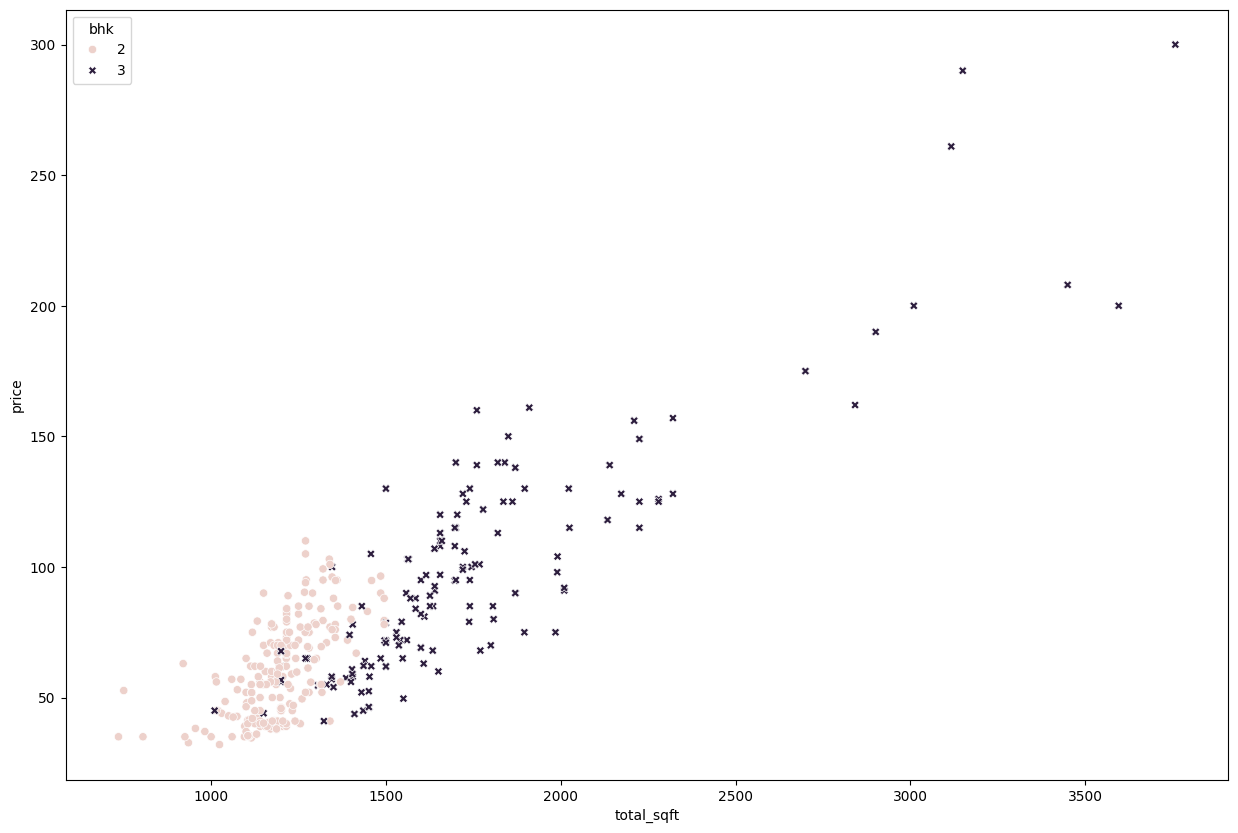

In [53]:
plot(df2,'Whitefield')

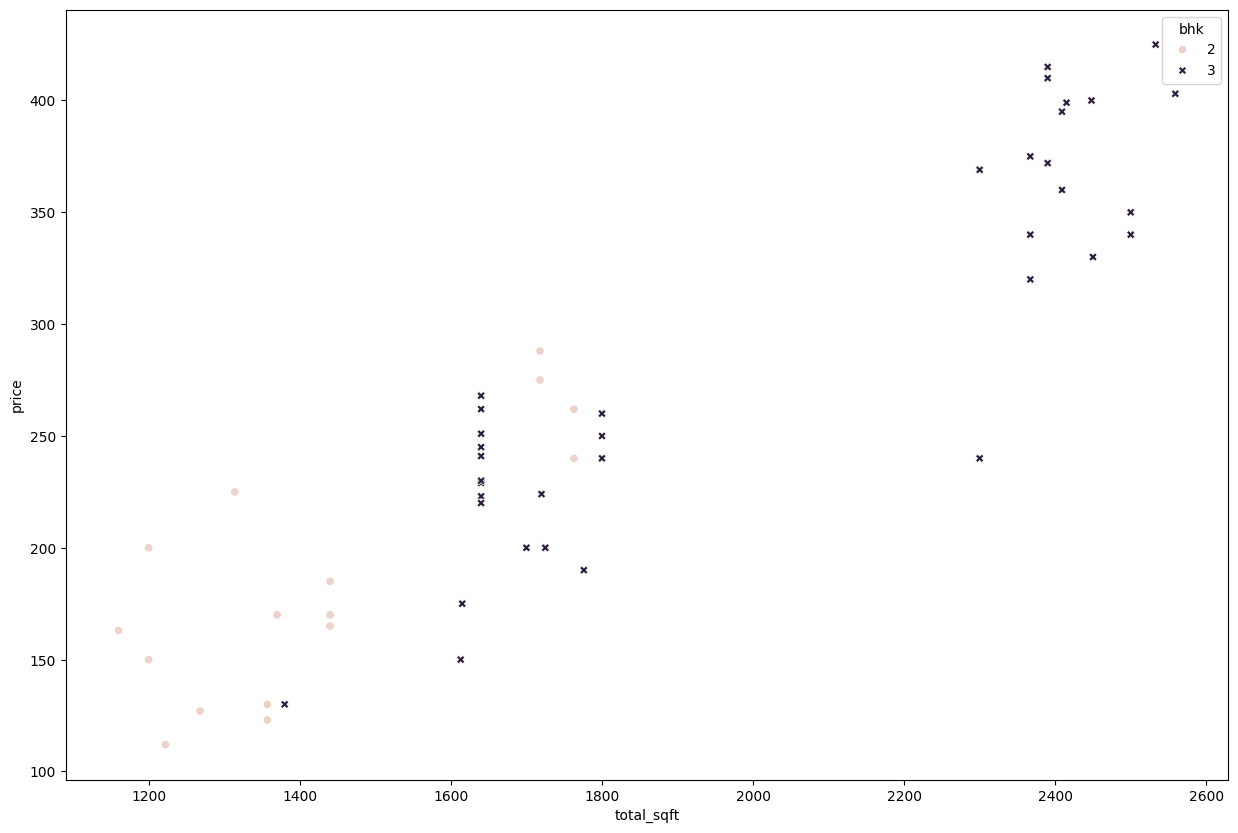

In [54]:
plot(df2,'Rajaji Nagar')

In [55]:
def remove_bhk_outliers(frame):
    exclude=[]
    for location,location_df in frame.groupby('location'):
        info={}
        for bhk,bhk_df in location_df.groupby('bhk'):
            info[bhk]={'mean':np.mean(bhk_df['price per sqft']),'count':bhk_df.shape[0]}
        for bhk,bhk_df in location_df.groupby('bhk'):
            prev_info=info.get(max((b for b in info if b<bhk),default=None))
            if prev_info and prev_info['count']>5:
                exclude.extend(bhk_df[bhk_df['price per sqft']<prev_info['mean']].index.values)
    return frame.drop(exclude,axis=0)

In [56]:
df3=remove_bhk_outliers(df2)
df3.head()

,location,total_sqft,bath,balcony,price,bhk,sq ft per bedroom,price per sqft
210,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,712.500000,15017.543860
848,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,543.333333,11901.840491
2152,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3,625.000000,12533.333333
7138,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3,400.000000,10833.333333
7358,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2,617.500000,11983.805668


In [57]:
df3.shape

(6925, 8)

In [58]:
df_final=df3.drop(['sq ft per bedroom','price per sqft'],axis=1)
df_final.head()

,location,total_sqft,bath,balcony,price,bhk
210,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4
848,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3
2152,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3
7138,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3
7358,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2


In [59]:
df_final=df_final.sample(frac=1,random_state=18).reset_index(drop=True)
df_final.head()

,location,total_sqft,bath,balcony,price,bhk
0,Subramanyapura,1277.0,2.0,2.0,55.00,2
1,Hebbal,1345.0,2.0,1.0,97.00,2
2,other,1280.0,2.0,1.0,75.00,2
3,Chandapura,590.0,1.0,0.0,13.57,1
4,Electronics City Phase 1,1800.0,3.0,2.0,93.00,3


In [60]:
df_final.shape

(6925, 6)

In [61]:
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import OneHotEncoder as ohe
from sklearn.preprocessing import StandardScaler as ss
from sklearn.compose import ColumnTransformer as ct
from sklearn.pipeline import Pipeline as p
from sklearn.model_selection import GridSearchCV as gsc
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression as lr
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.ensemble import RandomForestRegressor as rfr

In [62]:
x=df_final.drop(['price'],axis=1)
y=df_final['price']

In [63]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=18)

In [64]:
c=ct([('categorical',ohe(drop='first',handle_unknown='ignore',sparse_output=False),['location']),('numerical',ss(),['total_sqft','bath','balcony','bhk'])],remainder="passthrough")

In [65]:
p1=p([('transformer',c),('model',lr())])
p2=p([('transformer',c),('model',Lasso())])
p3=p([('transformer',c),('model',Ridge())])
p4=p([('transformer',c),('model',dtr())])
p5=p([('transformer',c),('model',rfr())])

In [66]:
param_grid = {
    'Linear Regression': {
        'model': p1,
        'params': {
        }
    },

    'Lasso': {
        'model': p2,
        'params': {
            'model__alpha': [0.001, 0.01, 0.1, 1, 10],
            'model__max_iter':[1000]
        }
    },

    'Ridge': {
        'model': p3,
        'params': {
            'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
            'model__max_iter':[1000]
        }
    },

    'Decision Tree': {
        'model': p4,
        'params': {
            'model__criterion': ['squared_error'],
            'model__max_depth': [3, 5, 10, 20, None]
        }
    },

    'Random Forest': {
        'model': p5,
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [10, 20, None]
        }
    }
}

In [67]:
cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=18)
cv_k=KFold(n_splits=5,shuffle=True,random_state=18)

In [205]:
scores=[]
for model,mp in param_grid.items():
    g=gsc(mp['model'],mp['params'],cv=cv,scoring='r2',n_jobs=-1)
    g.fit(x_train,y_train)
    scores.append({'Model':model,'Best_Score':g.best_score_,'Best_Params':g.best_params_})
    print(f"{model} done.")

C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(


Linear Regression done.


C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


Lasso done.


C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


Ridge done.


C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Decision Tree done.


C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Random Forest done.


In [206]:
pd.DataFrame(scores)

,Model,Best_Score,Best_Params
0,Linear Regression,NaN,{}
1,Lasso,NaN,"{'model__alpha': 0.001, 'model__max_iter': 1000}"
2,Ridge,NaN,"{'model__alpha': 0.001, 'model__max_iter': 1000}"
3,Decision Tree,NaN,"{'model__criterion': 'squared_error', 'model__..."
4,Random Forest,NaN,"{'model__max_depth': 10, 'model__min_samples_l..."


In [212]:
print(x_train.isnull().sum())
print(y_train.isnull().sum())

location      0
total_sqft    0
bath          0
balcony       0
bhk           0
dtype: int64
0


In [213]:
print(x_train.dtypes)

location       object
total_sqft    float64
bath          float64
balcony       float64
bhk             int64
dtype: object


In [219]:
Xt = c.fit_transform(x_train)
print("Shape:", Xt.shape)
print("Type:", type(Xt))

Shape: (5523, 257)
Type: <class 'scipy.sparse._csr.csr_matrix'>


In [220]:
print("Has NaN:", np.isnan(Xt.data).sum())
print("Has Inf:", np.isinf(Xt.data).sum())

Has NaN: 0
Has Inf: 0


In [226]:
model = p1
model.fit(x_train, y_train)

pred = model.predict(x_train)

print(np.isnan(pred).sum(), np.isinf(pred).sum())

0 0


In [244]:
scores=[]
best_models={}
for model,mp in param_grid.items():
    g=gsc(mp['model'],mp['params'],cv=cv_k,scoring='neg_root_mean_squared_error',n_jobs=-1)
    g.fit(x_train,y_train)
    best_models[model]=g.best_estimator_
    scores.append({'Model':model,'Best_Score':-g.best_score_,'Best_Params':g.best_params_})
    print(f"{model} done.")

Linear Regression done.
Lasso done.
Ridge done.
Decision Tree done.
Random Forest done.


In [245]:
pd.DataFrame(scores)

,Model,Best_Score,Best_Params
0,Linear Regression,35.128458,{}
1,Lasso,35.289579,"{'model__alpha': 0.001, 'model__max_iter': 1000}"
2,Ridge,35.075556,"{'model__alpha': 0.01, 'model__max_iter': 1000}"
3,Decision Tree,50.670092,"{'model__criterion': 'squared_error', 'model__..."
4,Random Forest,38.996967,"{'model__max_depth': None, 'model__n_estimator..."


In [247]:
final_model=best_models['Ridge']

In [249]:
final_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['location','total_sqft','bath','balcony','bhk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatena

In [250]:
final_model.score(x_test,y_test)

0.8694303539643864

In [264]:
x.head()

,location,total_sqft,bath,balcony,bhk
0,Panathur,1438.0,2.0,3.0,2
1,Electronics City Phase 1,1450.0,3.0,2.0,3
2,other,2100.0,3.0,0.0,4
3,Prithvi Layout,2028.0,4.0,3.0,4
4,Budigere,664.0,1.0,1.0,1


In [256]:
def predict(location,total_sqft,bathroom,balcony,bedroom):
    return final_model.predict(pd.DataFrame({'location':[location],
                                             'total_sqft':[total_sqft],
                                             'bath':[bathroom],
                                             'balcony':[balcony],
                                             'bhk':[bedroom]}))

In [258]:
predict('Whitefield',2785,5,3,4)

array([204.47037632])

In [261]:
predict('Rajaji Nagar',2400,3,2,3)

array([329.77700381])

In [262]:
import joblib

In [263]:
joblib.dump(final_model,'Bengaluru_housing_prices_project_model')

['Bengaluru_housing_prices_project_model']

In [68]:
import json

In [82]:
location=sorted(df_final['location'].unique())

In [83]:
with open('locations.json','w') as file:
    json.dump(location,file)